💡 **Environment:** `clamp-analyses`


# Supplementary Figure 4: CLAMPfull pathway coverage and saturation (ARCHS4 GO:BP pipeline)

The CLAMPfull counterparts of Fig. 3's CLAMPbase pathway panels (A, C, E), plus the
CLAMPfull saturation reference test (D, counterpart of Fig. 3's Panel F).


In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(patchwork)
  library(cowplot)
  library(ggrastr)
  library(ggpubr)
  library(yaml)
  library(here)
})


In [2]:
cfg <- yaml::read_yaml(here("config.yaml"))

FS_TAG          <- 9
FS_TITLE        <- 6.5
FS_AXIS_TITLE   <- 6.5
FS_AXIS_TEXT    <- 5
FS_LEGEND       <- 5
FS_LEGEND_TITLE <- 5.5

FIG_W <- 183
FIG_H <- 95
stopifnot(FIG_W == 183, FIG_H == 95)

DATA_DIR <- here("output/03_model_biology/02_archs4")

# Same palettes as workflow/config/archs4.yaml's archs4.coverage.colors,
# used throughout 00_coverage.ipynb / 00_saturation.ipynb.
ARCHS4_MODEL_COLORS   <- c(CLAMPfull = "#0072B2", CLAMPbase = "#777777")
ARCHS4_DATASET_COLORS <- c(ARCHS4 = "#0072B2", GTEx = "#E69F00", recount2 = "#009E73")
DATASET_NAMES <- c(archs4 = "ARCHS4", gtex = "GTEx", recount2 = "recount2")

theme_nm <- function(base_size = FS_AXIS_TEXT, base_line_size = 0.25) {
  theme_classic(base_size = base_size, base_family = "Helvetica") %+replace%
    theme(
      axis.line = element_line(linewidth = base_line_size, colour = "black"),
      axis.ticks = element_line(linewidth = base_line_size, colour = "black"),
      axis.ticks.length = unit(1.1, "mm"),
      axis.text = element_text(size = FS_AXIS_TEXT, colour = "black"),
      axis.title = element_text(size = FS_AXIS_TITLE, face = "plain", colour = "black"),
      legend.text = element_text(size = FS_LEGEND),
      legend.title = element_text(size = FS_LEGEND_TITLE, face = "plain"),
      legend.key = element_blank(),
      legend.background = element_blank(),
      strip.background = element_blank(),
      strip.text = element_text(size = FS_TITLE, face = "bold", margin = margin(b = 0.7)),
      panel.grid = element_blank(),
      plot.margin = margin(1.3, 1.3, 1.3, 1.3)
    )
}

add_tag <- function(p, label, x = 0.002, y = 0.998) {
  ggdraw() +
    draw_plot(p, x = 0, y = 0, width = 1, height = 1) +
    draw_label(label, x = x, y = y, hjust = 0, vjust = 1,
               size = FS_TAG, fontface = "bold", fontfamily = "Helvetica")
}


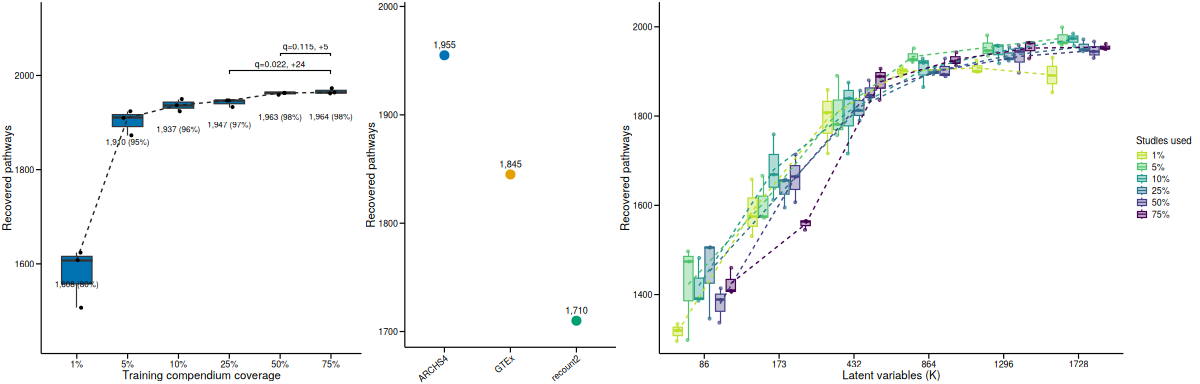

In [3]:
coverage_long <- fread(file.path(DATA_DIR, "00_coverage", "coverage_long.csv"))
coverage_long <- coverage_long[database != "reactome"]
FDR <- unique(coverage_long$fdr)
stopifnot(length(FDR) == 1L)

# A: pathway coverage vs. fraction, CLAMPfull (ARCHS4)
arch <- coverage_long[dataset == "archs4" & fraction < 100 & model == "CLAMPfull"]
arch_sum <- arch[, .(
  recovered_pathways = sum(recovered_pathways),
  eligible_pathways  = sum(eligible_pathways)
), by = .(fraction, seed)]
arch_sum[, fraction_label := factor(fraction, levels = sort(unique(fraction)),
                                     labels = sprintf("%s%%", sort(unique(fraction))))]

fraction_totals <- arch_sum[, .(
  recovered_pathways = as.integer(round(median(recovered_pathways))),
  eligible_pathways  = as.integer(round(median(eligible_pathways)))
), by = fraction]
fraction_totals[, fraction_label := factor(sprintf("%s%%", fraction),
                                           levels = levels(arch_sum$fraction_label))]
fraction_totals[, label := sprintf("%s (%.0f%%)", format(recovered_pathways, big.mark = ",", trim = TRUE),
                                   100 * recovered_pathways / eligible_pathways)]
fraction_totals[, label_y := recovered_pathways - 0.11 * diff(range(arch_sum$recovered_pathways))]

comparisons_A <- rbindlist(lapply(c(25L, 50L), function(fv) {
  ref  <- arch_sum[fraction == 75L][order(seed)]$recovered_pathways
  cand <- arch_sum[fraction == fv][order(seed)]$recovered_pathways
  data.table(group1 = sprintf("%s%%", fv), group2 = "75%",
             p = t.test(ref, cand, paired = TRUE, alternative = "greater")$p.value,
             difference = as.integer(round(mean(ref - cand))))
}))
comparisons_A[, p.adj := p.adjust(p, method = "BH")]
comparisons_A[, y.position := max(arch_sum$recovered_pathways) +
                seq_len(.N) * diff(range(arch_sum$recovered_pathways)) * 0.08]
comparisons_A[, label := sprintf("q=%.3f, %+d", p.adj, difference)]

plot_A <- ggplot(arch_sum, aes(fraction_label, recovered_pathways)) +
  geom_boxplot(fill = ARCHS4_MODEL_COLORS[["CLAMPfull"]], width = 0.6, outlier.shape = NA,
               linewidth = 0.25) +
  stat_summary(aes(group = 1), fun = median, geom = "line", linetype = "dashed",
               colour = "#222222", linewidth = 0.3) +
  geom_jitter(width = 0.10, height = 0, size = 0.5) +
  geom_text(data = fraction_totals, aes(fraction_label, label_y, label = label),
            inherit.aes = FALSE, size = 1.6) +
  ggpubr::stat_pvalue_manual(comparisons_A, label = "label", tip.length = 0.01, size = 1.7,
                              bracket.size = 0.25) +
  scale_y_continuous(expand = expansion(mult = c(0.18, 0.20))) +
  scale_x_discrete(expand = expansion(add = c(0.7, 0.6))) +
  labs(x = "Training compendium coverage",
       y = "Recovered pathways") +
  theme_nm()

# B: pathway coverage across compendia, full data, CLAMPfull (seed 1)
cross <- coverage_long[fraction == 100 & model == "CLAMPfull" & seed == 1L]
cross_sum_b <- cross[, .(recovered_pathways = sum(recovered_pathways)), by = dataset]
cross_sum_b[, dataset_label := factor(DATASET_NAMES[dataset],
                                      levels = DATASET_NAMES[c("archs4", "gtex", "recount2")])]
cross_sum_b[, label := format(recovered_pathways, big.mark = ",", trim = TRUE)]

plot_B <- ggplot(cross_sum_b, aes(dataset_label, recovered_pathways, colour = dataset_label)) +
  geom_point(size = 2.2) +
  geom_text(aes(label = label), vjust = -1.0, colour = "black", size = 1.8) +
  scale_colour_manual(values = ARCHS4_DATASET_COLORS, guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0.10, 0.20))) +
  labs(x = NULL, y = "Recovered pathways") +
  theme_nm() +
  theme(axis.text.x = element_text(angle = 40, hjust = 1))

# C: saturation vs. rank K, CLAMPfull
saturation_long <- fread(file.path(DATA_DIR, "01_saturation", "saturation_long.csv"))
saturation_long <- saturation_long[database != "reactome"]

sat <- saturation_long[dataset == "archs4" & model == "CLAMPfull", .(
  recovered_pathways = sum(recovered_pathways),
  eligible_pathways  = sum(eligible_pathways)
), by = .(fraction, k, seed)]
sat[, k_label := factor(k, levels = sort(unique(k)))]
sat[, fraction_label := factor(sprintf("%d%%", fraction),
                               levels = sprintf("%d%%", sort(unique(fraction))))]

DODGE_C <- position_dodge(width = 0.85)
dodge_offset <- function(g) {
  n <- nlevels(g)
  (as.integer(g) - (n + 1) / 2) * (0.85 / n)
}
means_C <- sat[, .(recovered_pathways = mean(recovered_pathways)), by = .(fraction_label, k_label)]
means_C[, x := as.integer(k_label) + dodge_offset(fraction_label)]

plot_C <- ggplot(sat, aes(k_label, recovered_pathways, fill = fraction_label, colour = fraction_label)) +
  geom_boxplot(position = DODGE_C, width = 0.75, outlier.shape = NA, alpha = 0.35, linewidth = 0.25) +
  geom_point(position = position_jitterdodge(jitter.width = 0.12, dodge.width = 0.85),
             size = 0.5, alpha = 0.65, show.legend = FALSE) +
  geom_line(data = means_C, aes(x = x, group = fraction_label),
            linetype = "dashed", linewidth = 0.3, show.legend = FALSE) +
  scale_fill_viridis_d(end = 0.9, direction = -1) +
  scale_colour_viridis_d(end = 0.9, direction = -1) +
  scale_y_continuous(expand = expansion(mult = c(0.04, 0.08))) +
  labs(x = "Latent variables (K)", y = "Recovered pathways",
       fill = "Studies used", colour = "Studies used") +
  theme_nm() +
  theme(legend.position = "right", legend.key.size = unit(2.5, "mm"))


# D: saturation reference test at largest K vs. 75%, CLAMPfull
# (CLAMPfull counterpart of Fig. 3's Panel F; reuses `sat` from Panel C.)
LAST_K_D <- max(sat$k)
REF_K_D  <- tail(levels(sat$fraction_label), 1L)

stars_for_D <- function(p) {
  ifelse(is.na(p), "n/a",
  ifelse(p < 0.001, "***",
  ifelse(p < 0.01, "**",
  ifelse(p < 0.05, "*", "ns"))))
}

sat_lastk_D <- droplevels(sat[k == LAST_K_D])
y_ref_D <- sat_lastk_D[fraction_label == REF_K_D, recovered_pathways]
others_D <- setdiff(levels(sat_lastk_D$fraction_label), REF_K_D)
ref_tests_D <- rbindlist(lapply(others_D, function(f) {
  x <- sat_lastk_D[fraction_label == f, recovered_pathways]
  if (length(x) < 2L || length(y_ref_D) < 2L) {
    return(data.table(fraction_label = f, n = length(x), n_ref = length(y_ref_D),
                       delta = NA_real_, p = NA_real_))
  }
  data.table(fraction_label = f, n = length(x), n_ref = length(y_ref_D),
             delta = mean(y_ref_D) - mean(x),
             p = t.test(y_ref_D, x, alternative = "greater", var.equal = TRUE)$p.value)
}))
ref_tests_D[, p_adj := p.adjust(p, method = "BH")]
ref_tests_D[, stars := stars_for_D(p_adj)]

lv_D <- levels(sat_lastk_D$fraction_label)
span_D <- range(sat_lastk_D$recovered_pathways)
yr_D <- diff(span_D)
st_D <- copy(ref_tests_D)[!is.na(delta)][order(match(fraction_label, lv_D))]
st_D[, `:=`(x = match(as.character(fraction_label), lv_D), xend = match(REF_K_D, lv_D))]
st_D[, y := span_D[2] + yr_D * (0.04 + 0.055 * seq_len(.N))]
fmt_p_D <- function(p) ifelse(p < 0.001, sprintf("%.1e", p), sprintf("%.3f", p))
st_D[, label := sprintf("q=%s (%+.0f)", fmt_p_D(p_adj), delta)]

plot_D <- ggplot(sat_lastk_D, aes(fraction_label, recovered_pathways, fill = fraction_label)) +
  geom_boxplot(width = 0.6, outlier.shape = NA, alpha = 0.35, linewidth = 0.3, show.legend = FALSE) +
  geom_jitter(width = 0.12, size = 0.7, alpha = 0.75, show.legend = FALSE) +
  geom_segment(data = st_D, aes(x = x, xend = xend, y = y, yend = y),
               inherit.aes = FALSE, colour = "#444444", linewidth = 0.3) +
  geom_segment(data = st_D, aes(x = x, xend = x, y = y, yend = y - yr_D * 0.02),
               inherit.aes = FALSE, colour = "#444444", linewidth = 0.3) +
  geom_segment(data = st_D, aes(x = xend, xend = xend, y = y, yend = y - yr_D * 0.02),
               inherit.aes = FALSE, colour = "#444444", linewidth = 0.3) +
  geom_text(data = st_D, aes(x = (x + xend) / 2, y = y + yr_D * 0.016, label = label),
            inherit.aes = FALSE, size = 1.7, colour = "#222222") +
  scale_fill_viridis_d(end = 0.9, direction = -1) +
  scale_y_continuous(expand = expansion(mult = c(0.04, 0.06))) +
  labs(x = "Studies used", y = "Recovered pathways") +
  theme_nm() +
  theme(legend.position = "none")

options(repr.plot.width = 10, repr.plot.height = 3.2)
plot_grid(plot_A, plot_B, plot_C, nrow = 1, rel_widths = c(1, 0.7, 1.6))


supp4: 183 x 95 mm -> /home/msubirana/Documents/pivlab/clamp-analyses-archs4_panel/output/99_panels/supp4


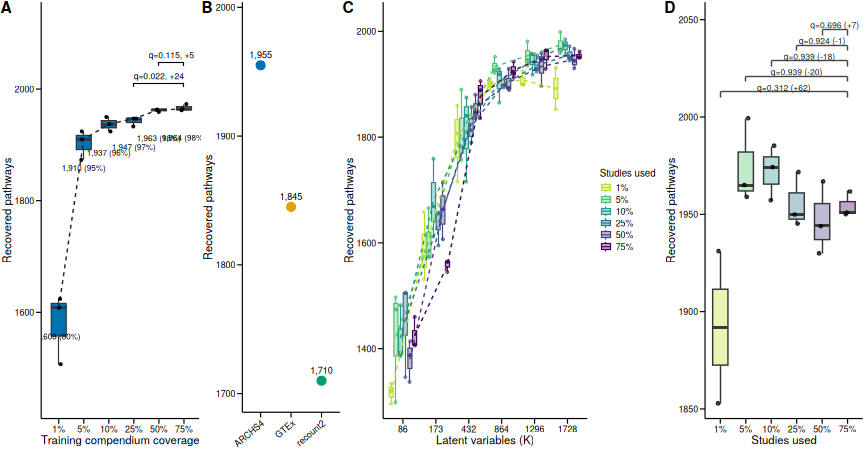

In [4]:
supp4 <- plot_grid(add_tag(plot_A, "A"), add_tag(plot_B, "B"), add_tag(plot_C, "C"), add_tag(plot_D, "D"),
                   nrow = 1, rel_widths = c(1, 0.7, 1.6, 1))

out_dir <- here("output/99_panels/supp4")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

raw_pdf <- tempfile(fileext = ".pdf")
ggsave(raw_pdf, supp4, width = FIG_W, height = FIG_H, units = "mm",
       device = cairo_pdf, bg = "white", limitsize = FALSE)

if (nzchar(Sys.which("gs"))) {
  exact_pdf <- tempfile(fileext = ".pdf")
  pdf_w_pt <- FIG_W / 25.4 * 72
  pdf_h_pt <- FIG_H / 25.4 * 72
  gs_status <- system2("gs", c(
    "-q", "-dNOPAUSE", "-dBATCH", "-sDEVICE=pdfwrite",
    sprintf("-dDEVICEWIDTHPOINTS=%.6f", pdf_w_pt),
    sprintf("-dDEVICEHEIGHTPOINTS=%.6f", pdf_h_pt),
    "-dFIXEDMEDIA", "-dPDFFitPage",
    paste0("-sOutputFile=", exact_pdf), raw_pdf
  ))
  stopifnot(gs_status == 0L)
  file.copy(exact_pdf, file.path(out_dir, "supp4.pdf"), overwrite = TRUE)
  unlink(exact_pdf)
} else {
  file.copy(raw_pdf, file.path(out_dir, "supp4.pdf"), overwrite = TRUE)
}
unlink(raw_pdf)

ggsave(file.path(out_dir, "supp4.svg"), supp4, width = FIG_W, height = FIG_H,
       units = "mm", device = svglite::svglite, bg = "white", limitsize = FALSE)
ggsave(file.path(out_dir, "supp4.png"), supp4, width = FIG_W, height = FIG_H,
       units = "mm", dpi = 600, device = ragg::agg_png, bg = "white", limitsize = FALSE)

cat(sprintf("supp4: %.0f x %.0f mm -> %s\n", FIG_W, FIG_H, out_dir))
options(repr.plot.width = FIG_W / 25.4, repr.plot.height = FIG_H / 25.4)
supp4
